In [ ]:
import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix

# -------------------------------
# 1. Directory Scan & Label Mapping
# -------------------------------
root_dir = '/content/drive/MyDrive/R1-Semantics-Dataset'  # Update with your root directory path
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

image_paths = []
labels = []

# Each subfolder in root_dir is a label.
for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    if os.path.isdir(folder_path):
        for fname in os.listdir(folder_path):
            if fname.lower().endswith(valid_extensions):
                image_paths.append(os.path.join(folder_path, fname))
                labels.append(folder_name)

import numpy as np
from collections import Counter

def balance_classes(image_paths, labels):
    # Count instances per class
    class_counts = Counter(labels)

    # Find the minimum class count
    min_count = min(class_counts.values())

    # Create a dictionary to store sampled indices per class
    sampled_indices = []

    for cls in class_counts.keys():
        # Get all indices for the class
        cls_indices = [i for i, label in enumerate(labels) if label == cls]
        # Randomly sample min_count instances
        sampled_indices.extend(np.random.choice(cls_indices, min_count, replace=False))

    # Create new balanced datasets
    new_image_paths = [image_paths[i] for i in sampled_indices]
    new_labels = [labels[i] for i in sampled_indices]

    return new_image_paths, new_labels

# Example usage
#balanced_image_paths, balanced_labels = balance_classes(image_paths, labels)
#image_paths = balanced_image_paths
#labels = balanced_labels
# Map string labels to integer indices.

# Convert to NumPy array (if not already)
image_paths = np.array(image_paths)
labels = np.array(labels)

# Generate a shuffled index
shuffle_indices = np.random.permutation(len(image_paths))

# Apply shuffle
image_paths_shuffled = image_paths[shuffle_indices]
labels_shuffled = labels[shuffle_indices]



unique_labels = sorted(set(labels))
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
labels_int = [label_to_index[label] for label in labels]
num_classes = len(unique_labels)
print("Found {} images across {} classes.".format(len(image_paths), num_classes))

# -------------------------------
# 2. Create a tf.data Pipeline with Lazy Loading
# -------------------------------
# Create a dataset from slices of image paths and labels.
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels_int))

def process_path(file_path, label):
    # Read the image from disk.
    image = tf.io.read_file(file_path)
    # Decode the image; using decode_image makes it work for different formats.
    image = tf.image.decode_image(image, channels=3)
    # Optionally set shape information if needed.
    image.set_shape([None, None, 3])
    # Resize the image to 224x224.
    image = tf.image.resize(image, [256, 256])
    # Normalize to [0, 1].
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Map the processing function to each sample.
dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

# Shuffle the dataset.
dataset = dataset.shuffle(buffer_size=len(image_paths), reshuffle_each_iteration=True)

# Split dataset into training (80%) and validation (20%).
val_size = int(0.2 * len(image_paths))
train_ds = dataset.skip(val_size)
val_ds = dataset.take(val_size)

# Batch and prefetch.
batch_size = 64
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)





Found 13356 images across 7 classes.


In [ ]:
# -------------------------------
# 3. Build a Decent Image Classification Model
# -------------------------------
def build_model(input_shape=(256, 256, 3), num_classes=7):
    inputs = tf.keras.Input(shape=input_shape)
    # Convolutional block 1
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)

    x = tf.keras.layers.MaxPooling2D()(x)

    # Convolutional block 2
    x = tf.keras.layers.SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    # Convolutional block 3
    x = tf.keras.layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    # Convolutional block 4
    x = tf.keras.layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    # Convolutional block 5
    x = tf.keras.layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    # Convolutional block 6
    x = tf.keras.layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    # Convolutional block 7
    x = tf.keras.layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    # Global pooling and dense layers.
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 16, 16, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 8, 8, 128)      │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 4, 4, 128)      │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,207 (340.65 KB)

 Trainable params: 87,207 (340.65 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# prompt: print and save the model as a png

tf.keras.utils.plot_model(model, to_file='classification.png', show_shapes=True, show_layer_names=True)
from google.colab import files
files.download('classification.png')
print(model.summary())


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 16, 16, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 8, 8, 128)      │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 4, 4, 128)      │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,207 (340.65 KB)

 Trainable params: 87,207 (340.65 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
for label, idx in label_to_index.items():
    print(f"Label: {label}, Assigned Integer: {idx}")

Label: Curls, Assigned Integer: 0
Label: Flecks, Assigned Integer: 1
Label: Mosaic, Assigned Integer: 2
Label: Powdery, Assigned Integer: 3
Label: Spots, Assigned Integer: 4
Label: Stripes, Assigned Integer: 5
Label: Velvety, Assigned Integer: 6


In [ ]:
# -------------------------------
# 4. Train the Model
# -------------------------------
epochs = 25
history = model.fit(train_ds,
                    epochs=epochs,
                    validation_data=val_ds)

# -------------------------------
# 5. Save the Model
# -------------------------------
model_save_path = "/content/drive/MyDrive/PlantVillage/classification_model.h5"
model.save(model_save_path)
print("Model saved to:", model_save_path)

# -------------------------------
# 6. Evaluate and Compute Confusion Matrix on Validation Set
# -------------------------------
# Evaluate overall metrics.
loss, accuracy = model.evaluate(val_ds)
print("Validation Loss: {:.4f}, Accuracy: {:.2%}".format(loss, accuracy))

# Collect predictions and true labels.
y_true = []
y_pred = []
for images, labels in val_ds:
    preds = model.predict(images)
    preds = tf.argmax(preds, axis=1)
    y_pred.extend(preds.numpy())
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)


Epoch 1/25
167/167 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - accuracy: 0.8367 - loss: 0.4242 - val_accuracy: 0.8379 - val_loss: 0.4349
Epoch 2/25
167/167 ━━━━━━━━━━━━━━━━━━━━ 34s 119ms/step - accuracy: 0.8550 - loss: 0.3748 - val_accuracy: 0.8869 - val_loss: 0.3058
Epoch 3/25
167/167 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.8680 - loss: 0.3319 - val_accuracy: 0.8997 - val_loss: 0.2798
Epoch 4/25
167/167 ━━━━━━━━━━━━━━━━━━━━ 33s 118ms/step - accuracy: 0.8795 - loss: 0.3055 - val_accuracy: 0.8925 - val_loss: 0.2796
Epoch 5/25
167/167 ━━━━━━━━━━━━━━━━━━━━ 33s 117ms/step - accuracy: 0.8932 - loss: 0.2874 - val_accuracy: 0.9064 - val_loss: 0.2401
Epoch 6/25
167/167 ━━━━━━━━━━━━━━━━━━━━ 33s 118ms/step - accuracy: 0.9011 - loss: 0.2567 - val_accuracy: 0.9075 - val_loss: 0.2371
Epoch 7/25
167/167 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.9075 - loss: 0.2334 - val_accuracy: 0.9176 - val_loss: 0.2080
Epoch 8/25
167/167 ━━━━━━━━━━━━━━━━━━━━ 33s 117ms/step - accuracy: 0.9117 - loss: 0

Model saved to: /content/drive/MyDrive/PlantVillage/classification_model.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9564 - loss: 0.0918
Validation Loss: 0.0954, Accuracy: 95.28%
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━

In [ ]:
# prompt: cm = confusion_matrix(y_true, y_pred) print confusion matrix in percentages without decimals

import numpy as np

cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
cm_percentage = np.round(cm_percentage).astype(int)
print("Confusion Matrix (Percentage):")
cm_percentage


Confusion Matrix (Percentage):


array([[ 91,   3,   0,   0,   3,   1,   1],
       [  0,  96,   0,   0,   1,   3,   0],
       [  0,   0, 100,   0,   0,   0,   0],
       [  0,   0,   0, 100,   0,   0,   0],
       [  0,   1,   0,   0,  98,   1,   0],
       [  0,  11,   0,   0,   2,  87,   0],
       [  0,   1,   0,   0,   0,   0,  99]])

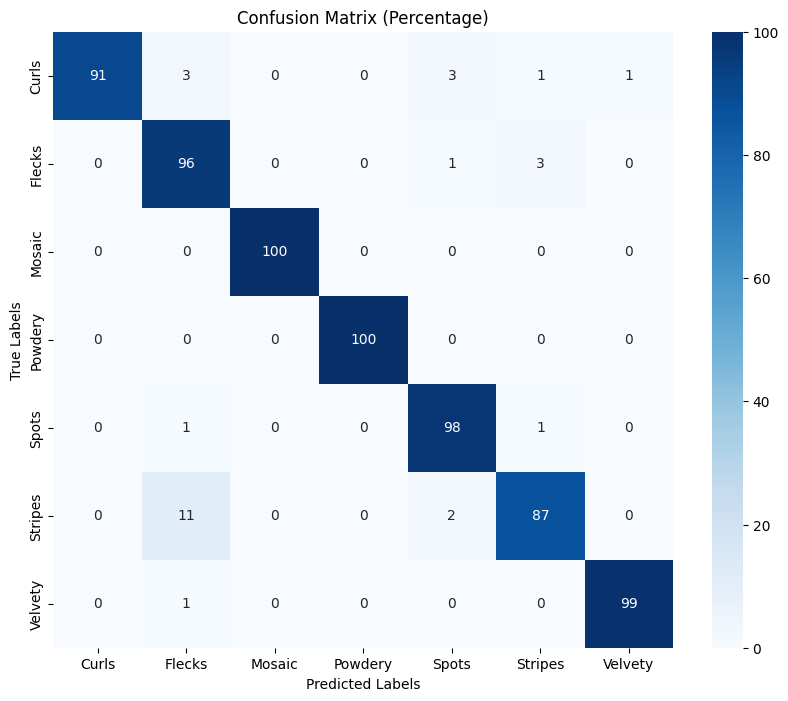

In [ ]:
# prompt: print the above confusion matrix as heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm_percentage, annot=True, fmt="d", cmap="Blues",
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Percentage)")
plt.show()


In [ ]:
# prompt: how do i get training graphs and AuC curves for the model

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Access training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


# Assuming 'y_true' and 'y_pred' (probabilities) from previous code
y_prob = model.predict(val_ds) # predict probabilities

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(np.eye(num_classes)[y_true][:, i], y_prob[:, i])  # Use one-hot encoded y_true
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i in range(num_classes):
  plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve per Class')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# prompt: give code to plot PR-AUC per class, and print f1 score per ach class

from sklearn.metrics import f1_score

# Calculate F1-score for each class
f1_scores = f1_score(y_true, y_pred, average=None)

# Print F1-scores
for i, score in enumerate(f1_scores):
    print(f"F1-score for class {i}: {score:.2f}")


In [ ]:
# prompt: print the class integers, label assigned to it and f1 score of each class, total accuracy in a table

import pandas as pd

# Assuming you have y_true, y_pred, and unique_labels from the previous code

# Create a list of dictionaries, one for each class
data = []
for i in range(num_classes):
  f1 = f1_score(np.array(y_true) == i, np.array(y_pred) == i) # Calculate F1 for each class individually
  data.append({
      'Class Integer': i,
      'Class Label': unique_labels[i],  # Use unique_labels to get the original string label
      'F1 Score': f1,
  })

# Create the pandas DataFrame
df = pd.DataFrame(data)

# Add a row with total accuracy at the end
total_accuracy = accuracy # assuming this variable has accuracy value from previous code
df.loc[len(df)] = ['Total', 'Accuracy', total_accuracy] #Add a row to the end of the dataframe.

# Print the DataFrame as a formatted table
df


In [ ]:
# prompt: Using dataframe df: plot the F1 scores ad bar graphs, with name of the class as labels on x and f1 on y

import altair as alt

# Create the bar chart
chart = alt.Chart(df).mark_bar().encode(
    x=alt.X('Class Label', sort=None),  # Use 'Class Label' for x-axis
    y='F1 Score'
).properties(
    title='F1 Scores per Class'
)

chart


In [ ]:
from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
from matplotlib import pyplot as plt
_df_1['F1 Score'].plot(kind='hist', bins=20, title='F1 Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# prompt: give code to plot PR-AUC per class

# Assuming 'y_true' and 'y_prob' (probabilities) from previous code
from sklearn.metrics import precision_recall_curve, auc

precision = dict()
recall = dict()
pr_auc = dict()

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(np.eye(num_classes)[y_true][:, i], y_prob[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

# Plot PR curves for each class
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(recall[i], precision[i], label=f'Class {i} (AUC = {pr_auc[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend(loc="lower left")
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_prob.max(axis=1), bins=50, kde=True)
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Model's Predicted Probabilities")
plt.show()


In [ ]:
# prompt: Label: Curls, Assigned Integer: 0
# Label: Flecks, Assigned Integer: 1
# Label: Mosaic, Assigned Integer: 2
# Label: Powdery, Assigned Integer: 3
# Label: Spots, Assigned Integer: 4
# Label: Stripes, Assigned Integer: 5
# Label: Velvety, Assigned Integer: 6
# these are my class mapping, can i have this on the confusion matrix instead of integer labels, print the confusion matrix as heat map.

import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# ... (Your existing code) ...

# -------------------------------
# 6. Evaluate and Compute Confusion Matrix on Validation Set
# -------------------------------
# ... (Your existing code) ...

cm = confusion_matrix(y_true, y_pred)

# Define the label mapping
label_mapping = {
    0: "Curls",
    1: "Flecks",
    2: "Mosaic",
    3: "Powdery",
    4: "Spots",
    5: "Stripes",
    6: "Velvety"
}

# Create a confusion matrix with string labels
cm_labels = [[label_mapping[j] for j in range(num_classes)] for i in range(num_classes)]
cm_labeled = np.zeros_like(cm, dtype=object)

for i in range(num_classes):
    for j in range(num_classes):
      cm_labeled[i][j] = str(cm[i][j])


plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(cm, annot=cm_labeled, fmt="", cmap="Blues",xticklabels=list(label_mapping.values()), yticklabels=list(label_mapping.values()))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


# ... (rest of your code) ...


In [ ]:
import os
import tensorflow as tf
import numpy as np

# -------------------------------
# Configuration for testing
# -------------------------------
test_folder = '/content/drive/MyDrive/PlantVillage/Semantics/Curls'  # Update with your test images folder
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
num_test_images = 100

# Load list of test image file paths.
test_image_files = [os.path.join(test_folder, fname)
                    for fname in os.listdir(test_folder)
                    if fname.lower().endswith(valid_extensions)]
test_image_files = test_image_files[:num_test_images]  # limit to 20 images

# -------------------------------
# Preprocessing function for a test image.
# -------------------------------
def load_and_preprocess_test_image(image_path, target_size=(256, 256)):
    # Read the image from disk.
    image = tf.io.read_file(image_path)
    # Decode the image to get a tensor.
    image = tf.image.decode_image(image, channels=3)
    # Provide static shape info (optional but useful).
    image.set_shape([None, None, 3])
    # Resize to target size.
    image = tf.image.resize(image, target_size)
    # Normalize pixel values to [0, 1].
    image = tf.cast(image, tf.float32) / 255.0
    return image

# -------------------------------
# Load the trained model.
# -------------------------------
model_save_path = "/content/drive/MyDrive/PlantVillage/classification_model.h5"
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model loaded for testing.")

# Assume unique_labels is available from your training code.
# If not, you should rebuild the mapping from your training labels.
# For example:
# unique_labels = sorted(set(training_labels))
# Here we assume it is available.
# unique_labels = ['class1', 'class2', 'class3', ...]

# -------------------------------
# Run inference on each test image and print results.
# -------------------------------
print("Testing on {} images:".format(len(test_image_files)))
for img_path in test_image_files:
    # Preprocess the image.
    image = load_and_preprocess_test_image(img_path)
    # Expand dims to add batch dimension.
    image_batch = tf.expand_dims(image, axis=0)

    # Run model prediction.
    prediction = loaded_model.predict(image_batch)
    pred_index = tf.argmax(prediction, axis=1).numpy()[0]
    pred_label = unique_labels[pred_index]

    print("Image: {}  -->  Predicted Label: {}".format(os.path.basename(img_path), pred_label))
